In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np


In [14]:

class DeepNetwork(nn.Module):
    """一个深层的普通神经网络"""
    def __init__(self, input_size, hidden_size, num_layers, output_size, activation='sigmoid'):
        super(DeepNetwork,self).__init__()
        self.num_layers = num_layers
        self.activation = activation

        #第一层
        self.layers = nn.ModuleList([nn.Linear(input_size,hidden_size)])

        #中间层
        for _ in range(num_layers - 2):
            self.layers.append(nn.Linear(hidden_size,hidden_size))

        # 输出层
        self.layers.append(nn.Linear(hidden_size,output_size))

    def forward(self, x):
        for i, layer in enumerate(self.layers[:-1]):
            x = layer(x)
            # 使用指定的激活函数
            if self.activation == 'sigmoid':
                x = torch.sigmoid(x)
            elif self.activation == 'tanh':
                x = torch.tanh(x)
            elif self.activation == 'relu':
                x = F.relu(x)

                    # 输出层不使用激活函数
        x = self.layers[-1](x)
        return x
    


In [15]:
# 创建网络
model = DeepNetwork(input_size=784, hidden_size=256, num_layers=20,
                    output_size=10, activation='sigmoid')

print(f"网络层数: {model.num_layers}")
print(f"总参数量: {sum(p.numel() for p in model.parameters())}")

网络层数: 20
总参数量: 1387786


In [16]:
def visualize_gradients(model, input_data, target):
    """可视化每一层的梯度大小"""
    # 前向传播
    output = model(input_data)
    loss = F.cross_entropy(output, target)

    # 反向传播
    model.zero_grad()
    loss.backward()

    # 收集每一层的梯度范数
    gradient_norms = []
    layer_names = []

    for i, layer in enumerate(model.layers):
        if layer.weight.grad is not None:
            grad_norm = layer.weight.grad.norm().item()
            gradient_norms.append(grad_norm)
            layer_names.append(f'Layer {i+1}')

    # 绘图
    plt.figure(figsize=(12, 6))
    plt.bar(range(len(gradient_norms)), gradient_norms)
    plt.xlabel('Layer')
    plt.ylabel('Gradient Norm')
    plt.title('Gradient Magnitude Across Layers')
    plt.xticks(range(len(gradient_norms)), layer_names, rotation=45)
    plt.yscale('log')  # 使用对数刻度
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('gradient_vanishing.png', dpi=150)
    plt.show()

    return gradient_norms


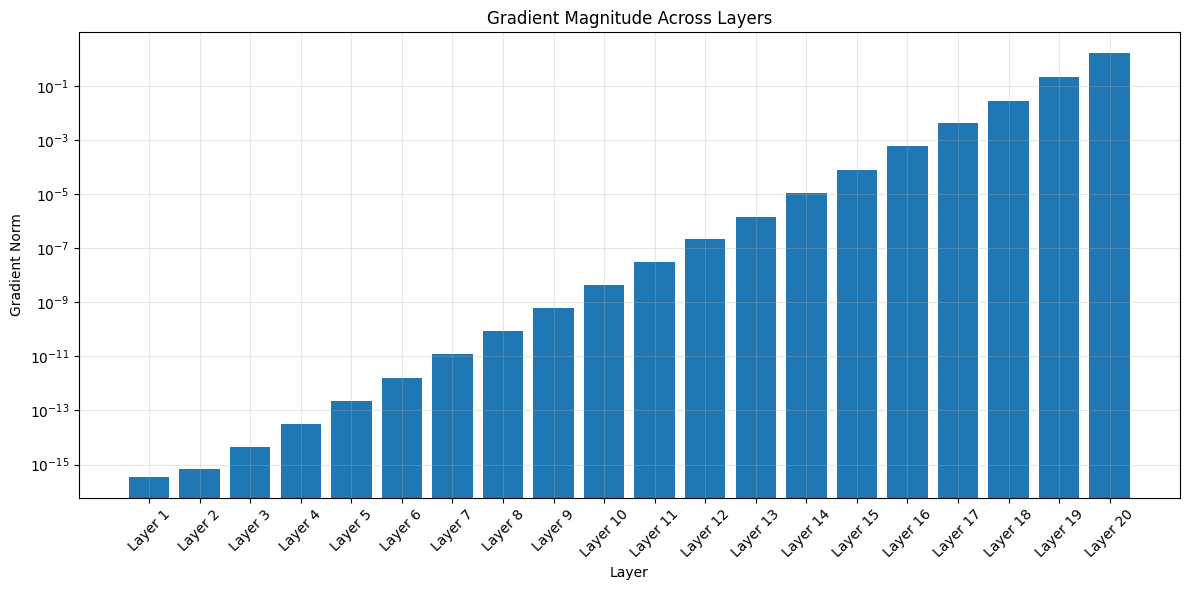


梯度统计:
第1层梯度范数: 0.000000
第10层梯度范数: 0.000000
第20层梯度范数: 1.625749
梯度衰减比例: 2.21e-16


In [17]:

# 创建随机输入
batch_size = 32
input_data = torch.randn(batch_size, 784)
target = torch.randint(0, 10, (batch_size,))

# 可视化梯度
gradient_norms = visualize_gradients(model, input_data, target)

# 打印梯度统计
print("\n梯度统计:")
print(f"第1层梯度范数: {gradient_norms[0]:.6f}")
print(f"第10层梯度范数: {gradient_norms[9]:.6f}")
print(f"第20层梯度范数: {gradient_norms[-1]:.6f}")
print(f"梯度衰减比例: {gradient_norms[0] / gradient_norms[-1]:.2e}")

In [18]:
def compare_activations(num_layers=20, num_trials=10):
    """对比不同激活函数的梯度传播"""
    activations = ['sigmoid', 'tanh', 'relu']
    results = {act: [] for act in activations}

    for activation in activations:
        print(f"\n测试激活函数: {activation}")

        for trial in range(num_trials):
            # 创建网络
            model = DeepNetwork(784, 256, num_layers, 10, activation)

            # 随机输入
            input_data = torch.randn(32, 784)
            target = torch.randint(0, 10, (32,))

            # 计算梯度
            output = model(input_data)
            loss = F.cross_entropy(output, target)
            model.zero_grad()
            loss.backward()

            # 收集第一层的梯度范数
            first_layer_grad = model.layers[0].weight.grad.norm().item()
            results[activation].append(first_layer_grad)

        avg_grad = np.mean(results[activation])
        std_grad = np.std(results[activation])
        print(f"  平均梯度范数: {avg_grad:.6f} ± {std_grad:.6f}")

    # 绘制对比图
    plt.figure(figsize=(10, 6))
    positions = range(len(activations))
    means = [np.mean(results[act]) for act in activations]
    stds = [np.std(results[act]) for act in activations]

    plt.bar(positions, means, yerr=stds, capsize=5, alpha=0.7)
    plt.xlabel('Activation Function')
    plt.ylabel('First Layer Gradient Norm')
    plt.title('Gradient Magnitude Comparison (20-layer network)')
    plt.xticks(positions, activations)
    plt.yscale('log')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('activation_comparison.png', dpi=150)
    plt.show()


测试激活函数: sigmoid
  平均梯度范数: 0.000000 ± 0.000000

测试激活函数: tanh
  平均梯度范数: 0.000102 ± 0.000009

测试激活函数: relu
  平均梯度范数: 0.000000 ± 0.000000


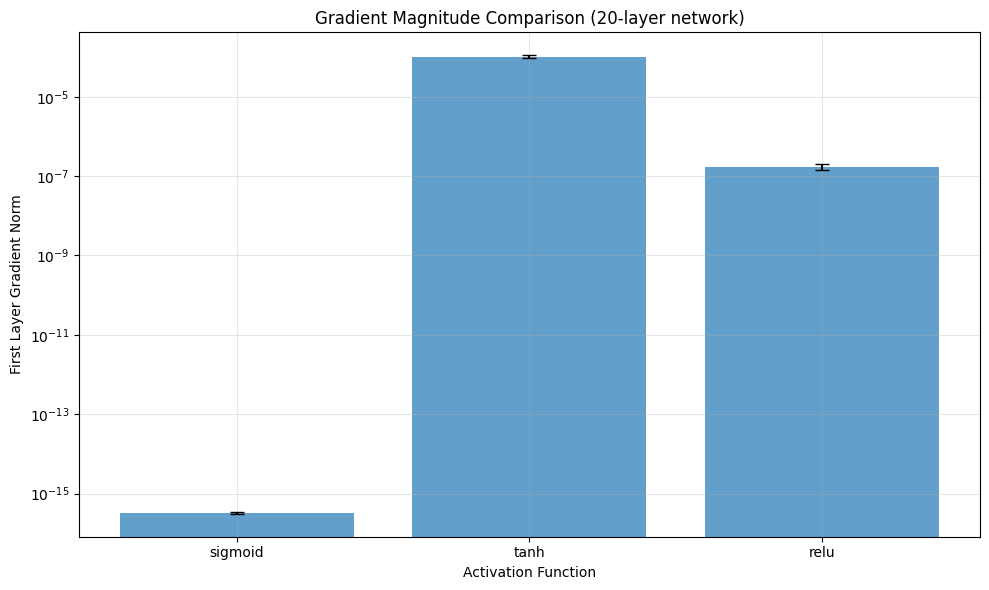

In [19]:
# 运行对比实验
compare_activations()

In [20]:
# 对比不同的网络权重初始方法
def initialize_weights(model, method='xavier'):
    """初始化网络权重"""
    for layer in model.layers:
        if isinstance(layer, nn.Linear):
            if method == 'xavier':
                nn.init.xavier_normal_(layer.weight)
            elif method == 'he':
                nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')
            elif method == 'small':
                nn.init.normal_(layer.weight, mean=0, std=0.01)
            elif method == 'large':
                nn.init.normal_(layer.weight, mean=0, std=1.0)

            if layer.bias is not None:
                nn.init.zeros_(layer.bias)

In [21]:
def compare_initializations():
    """对比不同初始化方法"""
    methods = ['small', 'xavier', 'he', 'large']
    results = {}

    for method in methods:
        print(f"\n测试初始化方法: {method}")

        # 创建网络
        model = DeepNetwork(784, 256, 20, 10, activation='relu')
        initialize_weights(model, method)

        # 测试梯度
        input_data = torch.randn(32, 784)
        target = torch.randint(0, 10, (32,))

        output = model(input_data)
        loss = F.cross_entropy(output, target)
        model.zero_grad()
        loss.backward()

        # 收集所有层的梯度
        grad_norms = []
        for layer in model.layers:
            if layer.weight.grad is not None:
                grad_norms.append(layer.weight.grad.norm().item())

        results[method] = grad_norms
        print(f"  第1层梯度: {grad_norms[0]:.6f}")
        print(f"  第20层梯度: {grad_norms[-1]:.6f}")

    # 绘制对比图
    plt.figure(figsize=(12, 6))
    for method in methods:
        plt.plot(range(1, len(results[method])+1), results[method],
                marker='o', label=method, alpha=0.7)

    plt.xlabel('Layer')
    plt.ylabel('Gradient Norm')
    plt.title('Gradient Flow with Different Initializations')
    plt.legend()
    plt.yscale('log')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('initialization_comparison.png', dpi=150)
    plt.show()




测试初始化方法: small
  第1层梯度: 0.000000
  第20层梯度: 0.000000

测试初始化方法: xavier
  第1层梯度: 0.009719
  第20层梯度: 0.005340

测试初始化方法: he
  第1层梯度: 4.530685
  第20层梯度: 7.268449

测试初始化方法: large
  第1层梯度: inf
  第20层梯度: inf


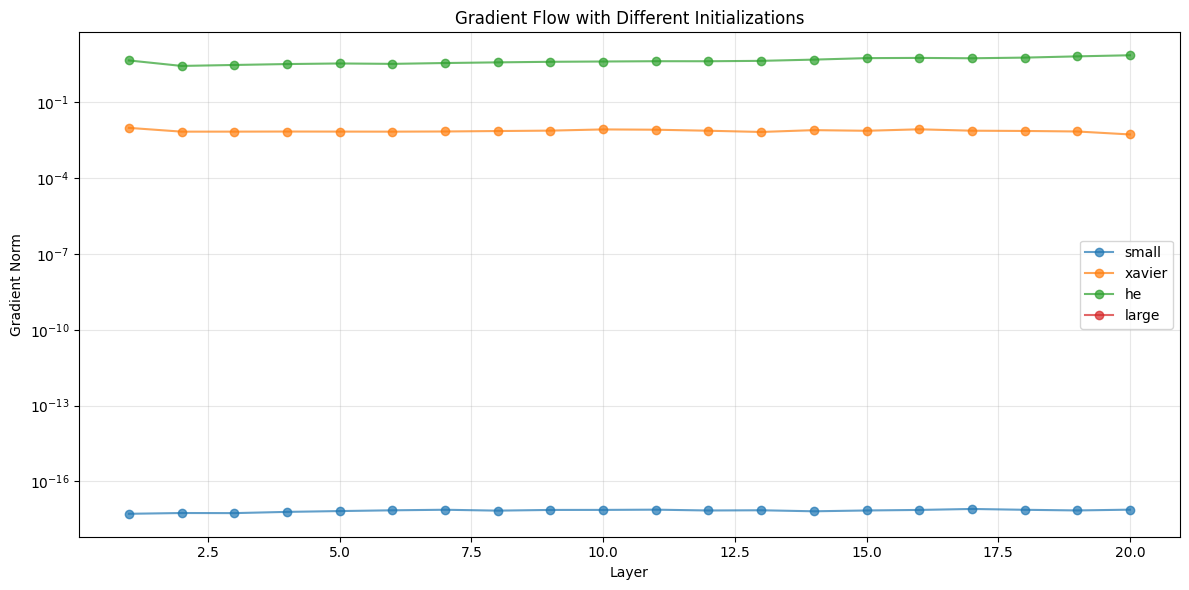

In [22]:
compare_initializations()